In [1]:
print("Hello, World!")

Hello, World!


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("../Dataset/Superstore.csv", encoding = 'latin1')

In [18]:
df.head

<bound method NDFrame.head of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       C

In [19]:
df.shape

(9994, 21)

In [20]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [21]:
df.info

<bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520      

In [22]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [25]:
df["Month"] = df["Order Date"].dt.to_period("M")

In [26]:
total_sales = df["Sales"].sum()
print(total_sales)

2297200.8603


In [27]:
total_profit = df["Profit"].sum()
print(total_profit)

286397.0217


In [28]:
total_orders = df["Order ID"].nunique()
print(total_orders)

5009


In [29]:
average_sales = df["Sales"].mean()
print(average_sales)

229.85800083049827


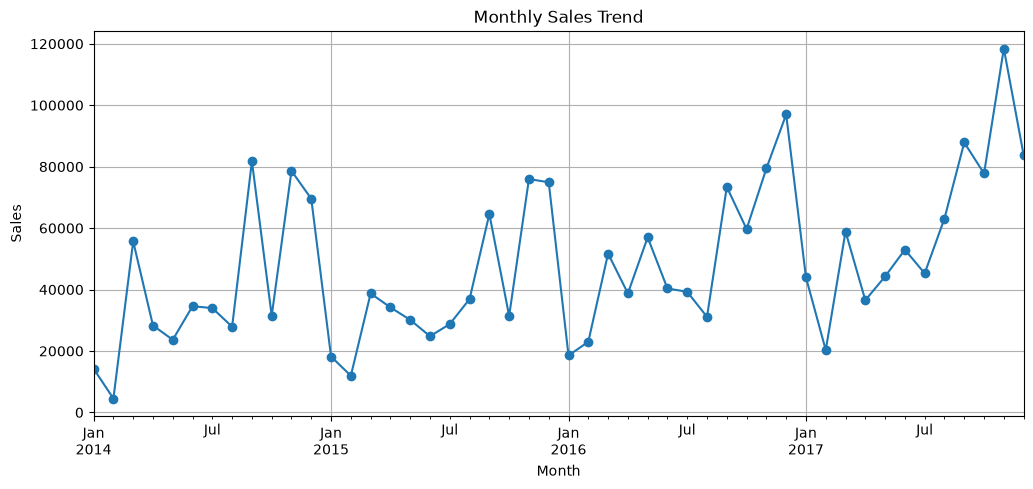

In [30]:
monthly_sales = df.groupby("Month")["Sales"].sum()
monthly_sales.plot(figsize = (12, 5), marker = "o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [31]:
plt.savefig("monthly_sales_trend.png")

<Figure size 640x480 with 0 Axes>

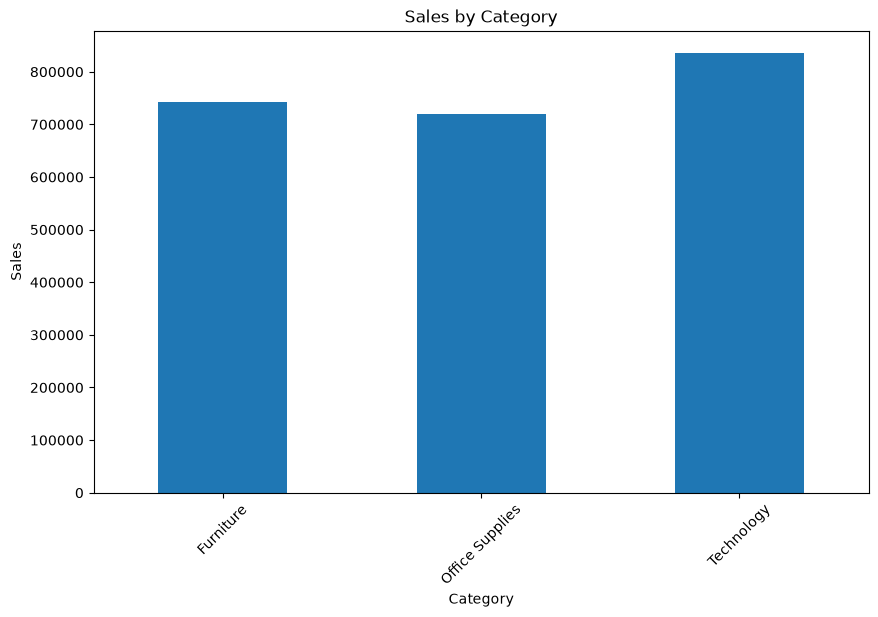

In [32]:
category_sales = df.groupby("Category")["Sales"].sum()
category_sales.plot(kind="bar", figsize=(10, 6))
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [33]:
plt.savefig("sales_by_category.png")

<Figure size 640x480 with 0 Axes>

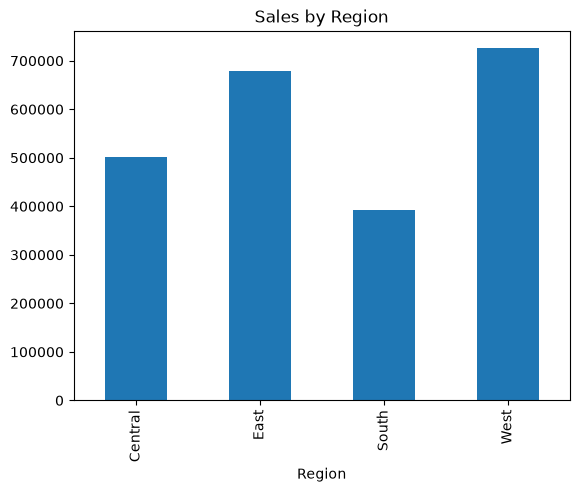

In [34]:
region_sales = df.groupby("Region")["Sales"].sum()
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.show()

In [35]:
plt.savefig("sales_by_region.png")

<Figure size 640x480 with 0 Axes>

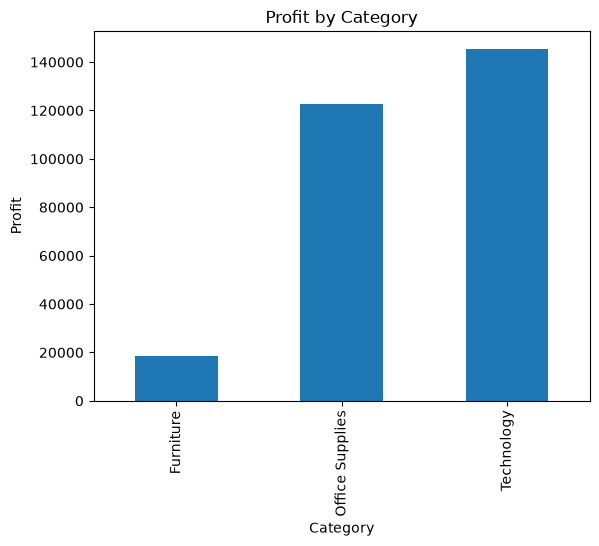

In [36]:
profit = df.groupby("Category")["Profit"].sum()
profit.plot(kind="bar")
plt.title("Profit by Category") 
plt.xlabel("Category")
plt.ylabel("Profit")    
plt.show()

In [37]:
plt.savefig("profit_by_category.png")

<Figure size 640x480 with 0 Axes>

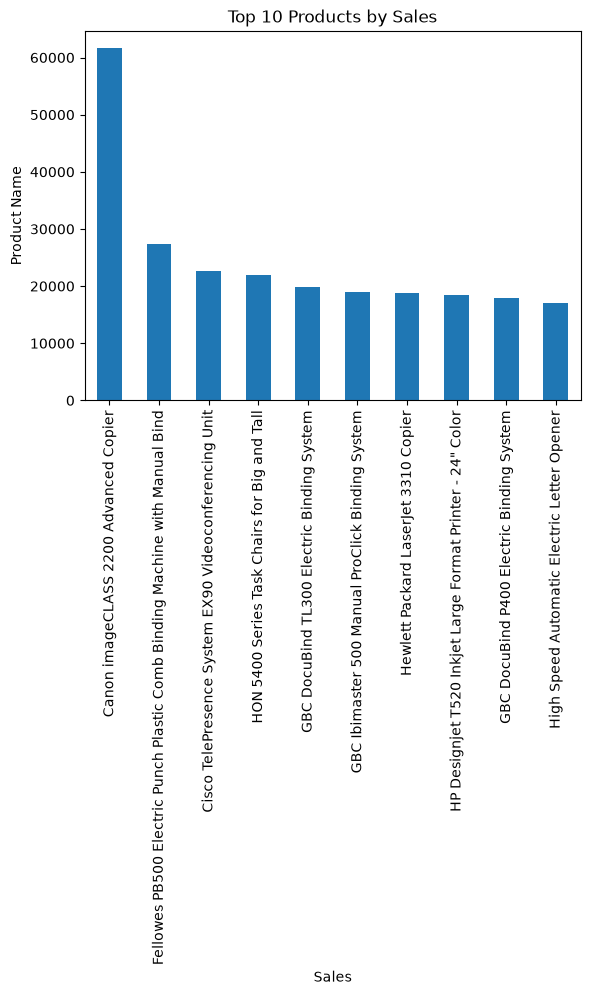

In [39]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.show()

In [40]:
plt.savefig("top_10_products_by_sales.png")

<Figure size 640x480 with 0 Axes>

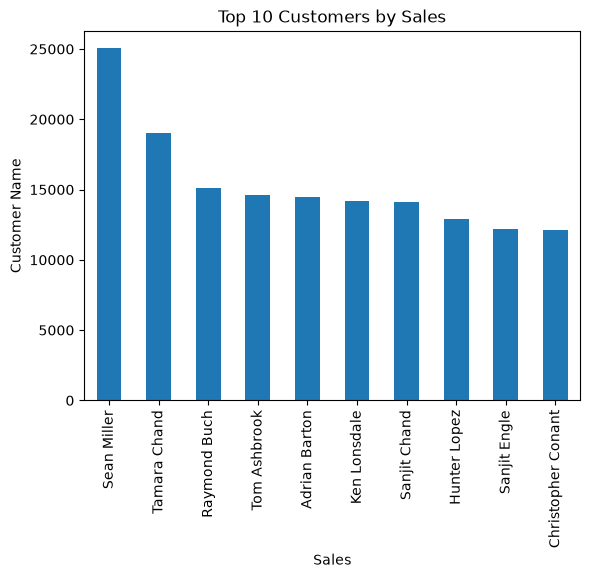

In [41]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind="bar")  
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales") 
plt.ylabel("Customer Name")
plt.show()

In [42]:
plt.savefig("top_10_customers_by_sales.png")

<Figure size 640x480 with 0 Axes>

In [43]:
print("==========KPI==========")
print(f"Total Sales: {total_sales:.2f}")
print(f"Total Profit: {total_profit:.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Sales: {average_sales:.2f}")        


==========KPI==========
Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Average Sales: 229.86
